In [1]:
%reload_ext autoreload
%autoreload 2

# import all the functions from the fastfeedback module
from fastfeedback import *

In [2]:
data_manager = DataManager("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")



Loading data...


/software/oz22897/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data with unique indices


In [3]:
bdt_results = pl.read_csv("bdt_scores_with_index_revised.csv")

data_manager.attach_bdt_scores(bdt_results, score_col="bdt_score")

data_manager.set_data_selection(data_manager.default_data_selection())
data_manager.set_nunubar_discrimination(Method.BDT, threshold=0.5116772973818791)

data_manager.set_direc_reco(Method.Reco)
data_manager.set_energy_reco(Method.Reco)
data_manager.set_flavor_discrimination(Method.Reco)
# data_manager.set_nunubar_discrimination(Method.Reco)
data = data_manager.prepare_data()


In [4]:
data

event_index,run,weight,flux_nue,flux_numu,xsec,nue_w,numu_w,osc_from_e_w,osc_from_mu_w,final_oscillated_w,genie_weight,nuPDG,Ev,isCC,NuMomY,mode,recoE_numu,recoE_nue,direc_numu,direc_nue,direc_nc,cvn_numu,cvn_nue,cvn_nc,npfps,direc_true,bdt_score,reco_pdg,recoE,direc_reco
u32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f32,bool,f32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f64,i32,f64,f64
0,0,2.4045136e7,0.002161,0.007993,3.63535,0.007857,0.029058,0.999988,0.000005,0.007857,2.4045136e7,-12,35.698929,true,5.325916,1,28.529816,28.432413,-0.167463,-0.291152,-0.291152,0.001684,0.994011,0.004305,9.0,-0.14919,0.579748,-12,28.432413,-0.291152
1,0,6.0056676e7,700.832829,1458.73821,0.000058,0.040934,0.085202,0.815649,0.004269,0.033752,6.0056676e7,-12,0.425595,true,-0.055933,0,0.322256,0.208079,0.092648,0.092648,0.092648,0.001051,0.986669,0.01228,1.0,0.131423,0.579192,-12,0.208079,0.092648
2,0,5.3239364e7,15.426308,37.089519,0.001919,0.0296,0.071168,0.009378,0.936898,0.066955,5.3239364e7,-14,1.668767,true,-0.83822,1,1.20171,1.156426,0.167917,0.169637,0.169637,0.982827,0.00081,0.016363,3.0,0.502299,0.427405,14,1.20171,0.167917
4,0,4.7361292e7,162.017806,343.329153,0.000198,0.0321,0.068023,0.021898,0.91852,0.063184,4.7361292e7,14,0.633065,true,-0.547973,0,0.5937,0.502835,0.568525,0.577708,0.577708,0.996696,0.000647,0.002657,2.0,0.865587,0.085535,14,0.5937,0.577708
5,0,4.2285008e7,41.355044,92.242325,0.000658,0.027228,0.060732,0.00021,0.003651,0.000227,4.2285008e7,16,1.200049,false,1.047497,0,0.914734,0.299485,-0.333278,-0.333278,-0.333278,0.003598,0.002786,0.993616,1.0,-0.872879,null,0,0.299485,-0.333278
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2884697,0,3.3414486e7,0.064264,0.176059,0.272591,0.017518,0.047992,0.000014,0.999613,0.047974,3.3414486e7,14,12.654237,true,3.211544,0,3.704717,0.893467,0.113819,0.130539,0.130539,0.968268,0.003848,0.027884,3.0,-0.253792,0.386088,14,3.704717,0.113819
2884698,0,4.7914404e7,50.127813,115.380758,0.000596,0.029898,0.068818,0.054774,0.210969,0.016156,4.7914404e7,14,1.042722,false,-0.966394,0,2.243878,0.156685,0.899609,0.899609,0.899609,0.527526,0.001337,0.471137,1.0,0.926799,0.514409,-14,0.156685,0.899609
2884699,0,2.5720664e7,1042.373838,2071.887123,0.000018,0.018585,0.036942,0.001904,0.945746,0.034973,2.5720664e7,14,0.31196,true,0.274496,0,0.260973,0.169946,-0.396677,-0.396677,-0.396677,0.99478,0.001054,0.004166,1.0,-0.879909,0.487104,14,0.260973,-0.396677


# I. Using the current reconstruction performance

In [5]:

import numpy as np
#Defining the binning for the true and reco energy and coszenith
Ebins = np.logspace(-1, 1, 200)
Czbins = np.linspace(-1, 1, 100)
Ebins_reco = np.logspace(-1, 1, 50)
Czbins_reco = np.linspace(-1, 1, 20)

#Creating the events distribution
ktyr = 25

eff_exposure = 160000/ktyr
events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)



Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


In [6]:
from tqdm import tqdm

#Gets the standard oscillation parameters
pars = get_nufit(MH.Normal)
#Compute the events with the standard oscillation parameters
events.compute_osc(pars)
#Saving the reference event rates
ref_event_rates = {fl: events.detected_events(fl) for fl in events.detected_channels}

LnL_values = {fl: [] for fl in events.detected_channels}

#Sampling dcp values
sampling = np.linspace(0, 2*np.pi, 50)
for val in tqdm(sampling):
    #Setting the dcp value
    pars.dcp = val
    #Computing the events with the new dcp value
    events.compute_osc(pars)
    #Saving the expected event rates
    expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

    #Computing the LnL values
    for ch in events.detected_channels:
        LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

#Converting the lists to numpy arrays
LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:37<00:00,  1.35it/s]


In [7]:
import iminuit
from iminuit import Minuit

def loss(dm21, dm31, th12, th13, th23, dcp):
    pars = ROOT.OscPars()
    pars.dm21 = dm21
    pars.dm31 = dm31
    pars.th12 = th12
    pars.th13 = th13
    pars.th23 = th23
    pars.dcp  = dcp
    
    events.compute_osc(pars)
    #Saving the expected event rates
    expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
    total_loss = 0
    for ch in events.detected_channels:
        total_loss += LnL(ref_event_rates[ch], expected[ch])
    # print(total_loss)
    return total_loss

nufit = get_nufit(MH.Normal)

fitter = iminuit.Minuit(loss, dm21=nufit.dm21, dm31=nufit.dm31, th12=nufit.th12, th13=nufit.th13, th23=nufit.th23, dcp=nufit.dcp)

In [8]:
# fitter.migrad()

In [9]:
fitter.hesse()

┌─────────────────────────────────────────────────────────────────────────┐
│                               External                                  │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 91               │
│ EDM = 6.72e-14 (Goal: 0.0002)    │           time = 48.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ dm21 │  0.07e-3  │  0.05e-3  │            │            │         │         │       │
│ 1 │ dm31 │  2.51e-3  │  0.06e-3  │            │            │         │         │       │
│ 2 │ th12 │    0.6    │    0.5    │            │            │         │         │       │
│ 3 │ th13 │   0.15    │   0.05    │            │            │         │         │       │
│ 4 │ th23 │   0.76    │   0.04    │            │            │         │         │       │
│ 5 │ dcp  │    3.7    │    1.6    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬───────────────────────────────────────────────────────────────────┐
│      │       dm21       dm31       th12       th13       th23        dcp │
├──────┼───────────────────────────────────────────────────────────────────┤
│ dm21 │   2.54e-09     2.1e-9 -6.7238e-6  -768.4e-9  -586.4e-9 31.0287e-6 │
│ dm31 │     2.1e-9   3.79e-09 -24.187e-6    -562e-9    -495e-9  40.403e-6 │
│ th12 │ -6.7238e-6 -24.187e-6        0.3    -0.0002     0.0017      -0.35 │
│ th13 │  -768.4e-9    -562e-9    -0.0002     0.0021     0.0000    -0.0038 │
│ th23 │  -586.4e-9    -495e-9     0.0017     0.0000     0.0015    -0.0044 │
│  dcp │ 31.0287e-6  40.403e-6      -0.35    -0.0038    -0.0044       2.63 │
└──────┴───────────────────────────────────────────────────────────────────┘

In [10]:

print(f"dcp error: {fitter.errors}")


dcp error: <ErrorView dm21=5.042679486316922e-05 dm31=6.157876576089782e-05 th12=0.5474488022632247 th13=0.04585935861227023 th23=0.038728101547270896 dcp=1.622530159164321>


In [30]:
fitter.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 136              │
│ EDM = 1.63e-13 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ dm21 │  0.07e-3  │  0.20e-3  │            │            │         │         │       │
│ 1 │ dm31 │  2.51e-3  │  0.25e-3  │            │            │         │         │       │
│ 2 │ th12 │    0.6    │    2.2    │            │            │         │         │       │
│ 3 │ th13 │   0.15    │   0.18    │            │            │         │         │       │
│ 4 │ th23 │   0.76    │   0.15    │            │            │         │         │       │
│ 5 │ dcp  │     4     │     6     │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬───────────────────────────────────────────────────────────────────┐
│      │       dm21       dm31       th12       th13       th23        dcp │
├──────┼───────────────────────────────────────────────────────────────────┤
│ dm21 │   4.05e-08    0.03e-6 -106.23e-6  -11.99e-6   -9.37e-6  489.86e-6 │
│ dm31 │    0.03e-6   6.05e-08 -384.15e-6   -8.60e-6   -7.87e-6  632.23e-6 │
│ th12 │ -106.23e-6 -384.15e-6       4.76     -0.002      0.027         -6 │
│ th13 │  -11.99e-6   -8.60e-6     -0.002     0.0333      0.001     -0.059 │
│ th23 │   -9.37e-6   -7.87e-6      0.027      0.001     0.0238     -0.067 │
│  dcp │  489.86e-6  632.23e-6         -6     -0.059     -0.067       41.7 │
└──────┴───────────────────────────────────────────────────────────────────┘

In [31]:
# fig, ax = plt.subplots()
# cx_base, cy_base = fitter.contour("dcp", "dm31", size=20)
# ax.plot(cx_base, cy_base, label="Baseline", color="blue")

# plt.xlabel("dcp")
# plt.ylabel("dm31")
# plt.show()

In [32]:
raise StopIteration("dont want everything right now")

StopIteration: dont want everything right now

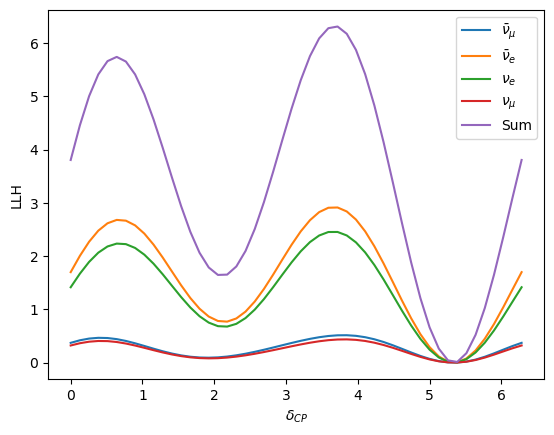

In [ ]:
latex_names = {
    Flavor.NuE: r"$\nu_e$",
    Flavor.NuMu: r"$\nu_\mu$",
    Flavor.NuMuBar: r"$\bar{\nu}_\mu$",
    Flavor.NuEBar: r"$\bar{\nu}_e$",
    Flavor.NuTau: r"$\bar{\nu}_\tau$",
    Flavor.NuTauBar: r"$\bar{\nu}_\tau$",
}


plt.figure()
sum = 0
for ch, values in LnL_values.items():
    if ch == Flavor.NC:
        continue
    sum += values
    plt.plot(sampling, values, label=latex_names[ch])
plt.plot(sampling, sum, label="Sum")
plt.xlabel(r'$\delta_{CP}$')
plt.ylabel('LLH')
plt.legend()

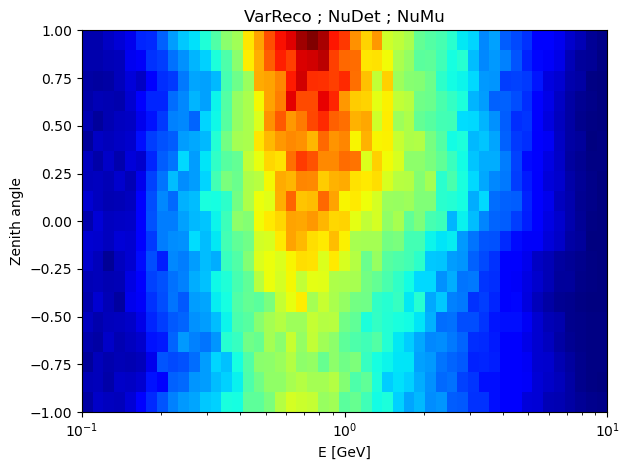

In [ ]:
#Plotting some event distributions
pars = get_nufit(MH.Normal)
events.compute_osc(pars)
fig = events.plot_distrib(VarType.VarReco, NuAxis.NuDet, Flavor.NuMu, oscillated=True)

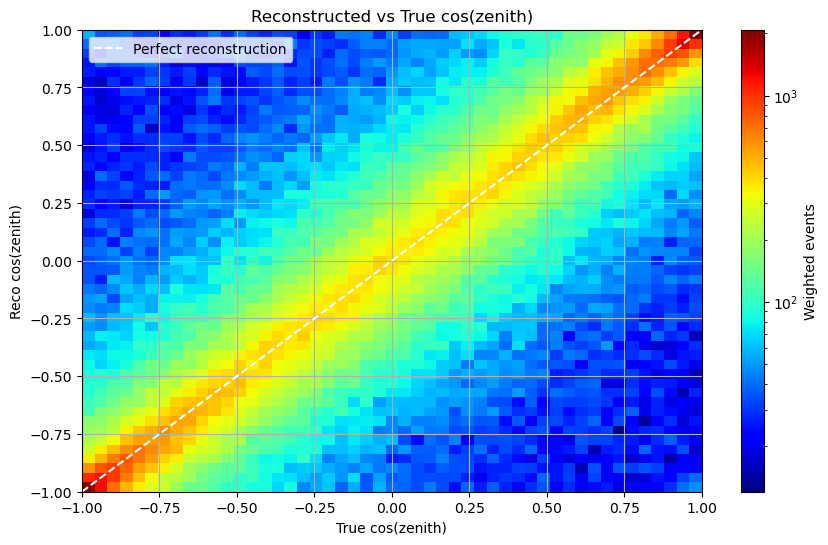

In [ ]:
def reco_dir_plot(data):
    plt.figure(figsize=(10, 6))
    cc = data.filter(
        pl.col('isCC'),
        pl.col('reco_pdg') == 14
    )
    plt.hist2d(cc['direc_true'], cc['direc_reco'], bins=np.linspace(-1, 1, 50), cmap='jet', norm='log')
    plt.colorbar(label='Weighted events')
    plt.plot([-1, 1], [-1, 1], color='white', linestyle='--', label='Perfect reconstruction')
    plt.xlabel('True cos(zenith)')
    plt.ylabel('Reco cos(zenith)')
    plt.title('Reconstructed vs True cos(zenith)')
    plt.legend()
    plt.grid()
    plt.show()

reco_dir_plot(data)

/tmp/ipykernel_942909/1176349466.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('count'),
/tmp/ipykernel_942909/1176349466.py:12: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  matrix = groups.pivot(


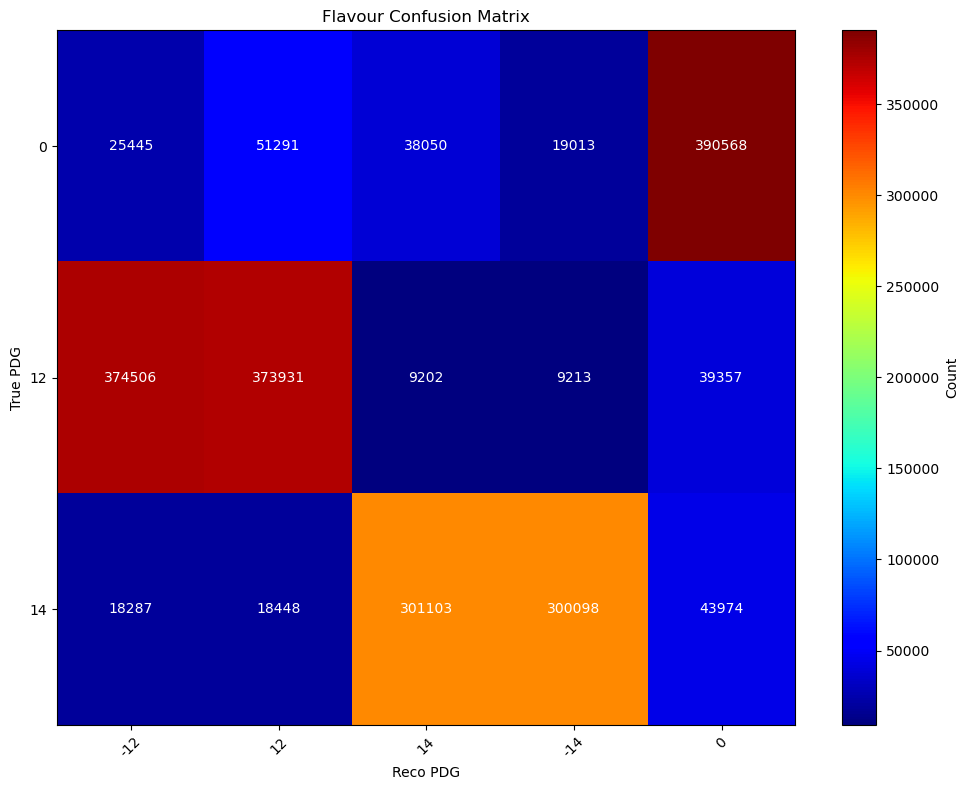

In [ ]:
def flavour_confusion_matrix(events):
    df = events.with_columns(
        true_pdg=pl.col('nuPDG').abs() * pl.col('isCC'),
    ).filter(
        pl.col('true_pdg').abs() != 16
    )

    groups = df.group_by(['true_pdg', 'reco_pdg']).agg(
        pl.count().alias('count'),
    ).sort('true_pdg')

    matrix = groups.pivot(
        index='true_pdg',
        columns='reco_pdg',
        values='count',
        aggregate_function='sum',
    ).fill_null(0).sort('true_pdg')

    return matrix

matrix = flavour_confusion_matrix(data)
plt.figure(figsize=(10, 8))
plt.imshow(matrix.to_numpy()[:, 1:], cmap='jet', aspect='auto')

#Also write values on the matrix
for i in range(len(matrix['true_pdg'])):
    for j in range(1, len(matrix.columns)):
        plt.text(j-1, i, int(matrix.to_numpy()[i, j]), ha='center', va='center', color='white')

plt.colorbar(label='Count')
plt.xticks(ticks=np.arange(len(matrix.columns)-1), labels=matrix.columns[1:], rotation=45)
plt.yticks(ticks=np.arange(len(matrix['true_pdg'])), labels=matrix['true_pdg'])
plt.xlabel('Reco PDG')
plt.ylabel('True PDG')
plt.title('Flavour Confusion Matrix')
plt.tight_layout()

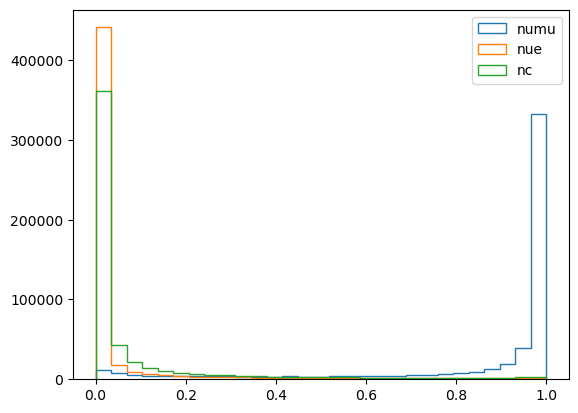

In [ ]:
numu = data.filter(
    pl.col('nuPDG') == 14,
    pl.col('isCC')
)
plt.hist(numu['cvn_numu'], bins=np.linspace(0, 1, 30), histtype='step', label='numu');
plt.hist(numu['cvn_nue'], bins=np.linspace(0, 1, 30), histtype='step', label='nue');
plt.hist(numu['cvn_nc'], bins=np.linspace(0, 1, 30), histtype='step', label='nc');
plt.legend()

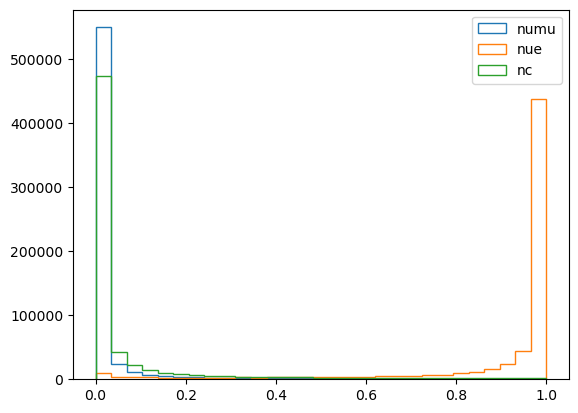

In [ ]:
numu = data.filter(
    pl.col('nuPDG') == 12,
    pl.col('isCC')
)
plt.hist(numu['cvn_numu'], bins=np.linspace(0, 1, 30), histtype='step', label='numu');
plt.hist(numu['cvn_nue'], bins=np.linspace(0, 1, 30), histtype='step', label='nue');
plt.hist(numu['cvn_nc'], bins=np.linspace(0, 1, 30), histtype='step', label='nc');
plt.legend()

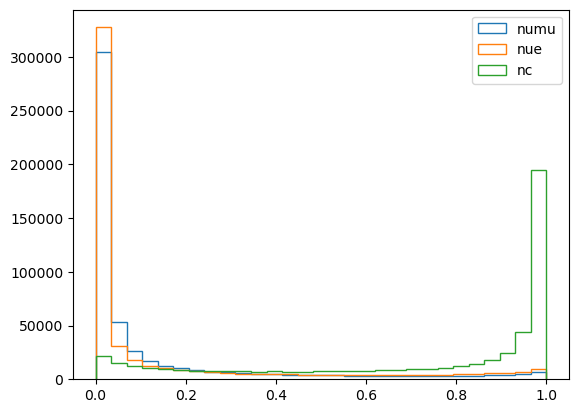

In [ ]:
nc = data.filter(
    ~pl.col('isCC')
)
plt.hist(nc['cvn_numu'], bins=np.linspace(0, 1, 30), histtype='step', label='numu');
plt.hist(nc['cvn_nue'], bins=np.linspace(0, 1, 30), histtype='step', label='nue');
plt.hist(nc['cvn_nc'], bins=np.linspace(0, 1, 30), histtype='step', label='nc');
plt.legend()

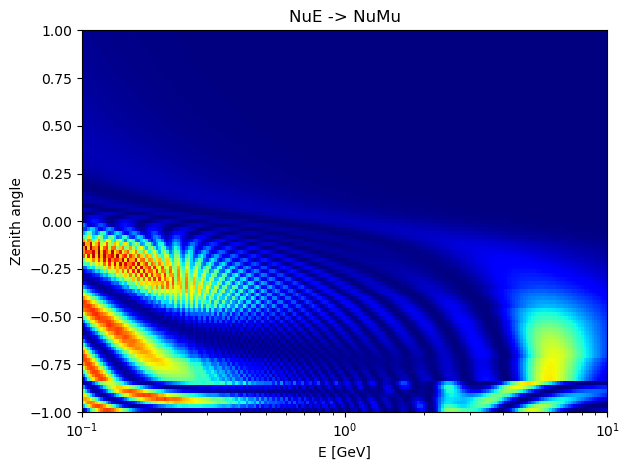

In [ ]:
#Plotting some oscillograms
fig = events.get_oscillogram(Flavor.NuE, Flavor.NuMu)

# II. Tweaking some resolutions by hand

### What happens to the dCP sensitivity if we can make some nu/nubar separation?

In [ ]:
data_manager.set_direc_reco(Method.Reco)
data_manager.set_energy_reco(Method.Reco)
data_manager.set_flavor_discrimination(Method.Reco)

efficiencies = {
    Flavor.NuE: 1,
    Flavor.NuEBar: 1,
    Flavor.NuMu: 1,
    Flavor.NuMuBar: 1,
    Flavor.NuTau: 1,
    Flavor.NuTauBar: 1,
}
nunubar = FakeEfficiency(efficiencies)
data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
data = data_manager.prepare_data()
events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


100%|██████████| 50/50 [00:36<00:00,  1.37it/s]


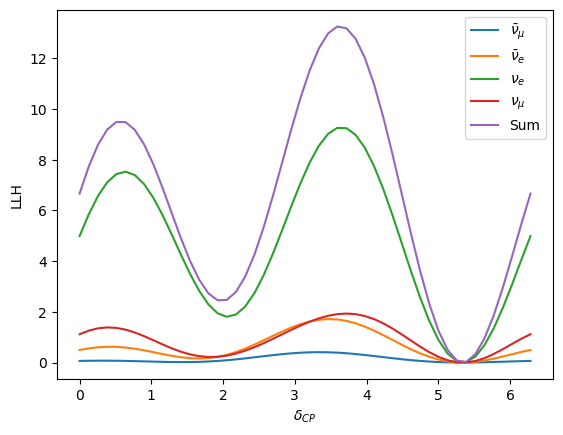

In [ ]:
#Updated sensitivity

#Gets the standard oscillation parameters
pars = get_nufit(MH.Normal)
#Compute the events with the standard oscillation parameters
events.compute_osc(pars)
#Saving the reference event rates
ref_event_rates = {fl: events.detected_events(fl) for fl in events.detected_channels}

LnL_values = {fl: [] for fl in events.detected_channels}

#Sampling dcp values
sampling = np.linspace(0, 2*np.pi, 50)
for val in tqdm(sampling):
    #Setting the dcp value
    pars.dcp = val
    #Computing the events with the new dcp value
    events.compute_osc(pars)
    #Saving the expected event rates
    expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

    #Computing the LnL values
    for ch in events.detected_channels:
        LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

#Converting the lists to numpy arrays
LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

plt.figure()
sum = 0
for ch, values in LnL_values.items():
    if ch == Flavor.NC:
        continue
    sum += values
    plt.plot(sampling, values, label=latex_names[ch])
plt.plot(sampling, sum, label="Sum")
plt.xlabel(r'$\delta_{CP}$')
plt.ylabel('LLH')
plt.legend()

**We can see some sensitivity improvement**

In [ ]:
# data_manager.set_direc_reco(Method.Reco)
# data_manager.set_energy_reco(Method.Reco)
# data_manager.set_flavor_discrimination(Method.Reco)
# data_manager.set_nunubar_discrimination(Method.Reco)

# #Adding some fake resolution for the energy (can also be done for the direction)
# Ebins_fake = np.logspace(-1, 1, 100)
# Eres = np.ones(len(Ebins_fake)+1)*0.1
# Efake = FakeResolution(Ebins_fake, Eres, pl.col('Ev'))
# data_manager.set_energy_reco(Method.Efficiency, Efake)

# data = data_manager.prepare_data()
# events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

# #To be continued...

## Added code

In [ ]:
cheated_params = ["dm21", "dm31", "th12", "th13", "th23"]
dcp_values = []
dcp_errors = []
true_params = get_nufit(MH.Normal)

for param in cheated_params:
    for p in cheated_params: fitter.fixed[p] = False 
    fitter.values[param] = getattr(true_params, param)
    fitter.fixed[param] = True
    fitter.migrad()
    fitter.hesse()
    dcp_values.append(fitter.values["dcp"])
    dcp_errors.append(fitter.errors["dcp"])

for p in cheated_params:
    fitter.values[p] = getattr(true_params, p)
    fitter.fixed[p] = True

fitter.migrad()
fitter.hesse()

labels = cheated_params + ["All Fixed"]
plot_values = dcp_values + [fitter.values["dcp"]]
plot_errors = dcp_errors + [fitter.errors["dcp"]]



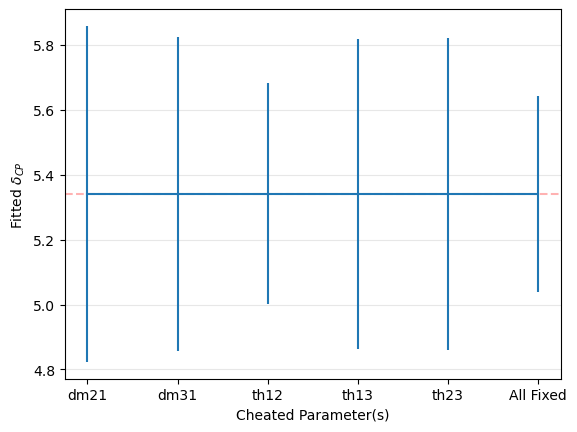

In [ ]:

plt.errorbar(labels, plot_values, yerr=plot_errors)
plt.axhline(5.34, color='red', linestyle='--', alpha=0.3) 
plt.ylabel(r"Fitted $\delta_{CP}$")
plt.xlabel("Cheated Parameter(s)")
plt.grid(axis='y', alpha=0.3)
plt.show()